In [ ]:
# Setup and Imports
# Data Manipulation & Structuring
import pandas as pd
import numpy as np

# Advanced Statistical Computing & Math
from scipy import stats

# Data Visualisation & Dashboard Prototype Construction
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning Algorithms & Evaluation Metrics Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [ ]:
# Load data
# Upload the file first:
from google.colab import files
uploaded = files.upload()  # select Customer-Churn-Records.csv

Saving Customer-Churn-Records.csv to Customer-Churn-Records (1).csv


In [ ]:
df = pd.read_csv('Customer-Churn-Records.csv')
print("Shape:", df.shape)
df.head()

Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [ ]:
# Structured cleaning
# Drop identifier / noise columns
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Check duplicates and nulls
print("Duplicate rows:", df.duplicated().sum())
print("\nNull values per column:\n", df.isna().sum())

# Normalize text/categorical fields
df['Card Type'] = df['Card Type'].str.strip().str.upper()
df['Geography'] = df['Geography'].str.strip()
df['Gender'] = df['Gender'].str.strip()

df.info()

Duplicate rows: 0

Null values per column:
 CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non

In [ ]:
# Outlier detection
num_cols_for_z = ['Balance', 'EstimatedSalary', 'CreditScore']
z_scores = np.abs(stats.zscore(df[num_cols_for_z]))

outlier_mask = (z_scores > 3).any(axis=1)
print(f"Number of outlier rows (|Z| > 3): {outlier_mask.sum()}")

df_outliers = df[outlier_mask]
df_outliers.head()

# Not dropping outliers here since churn signals can be legitimate extreme values —
# flag them instead for transparency in the report
df['is_outlier'] = outlier_mask.astype(int)

Number of outlier rows (|Z| > 3): 8


In [ ]:
# Age Binning (Generational Buckets)
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,42,36-45
1,41,36-45
2,42,36-45
3,39,36-45
4,43,36-45


In [ ]:
# Export Cleaned data
df.to_csv('cleaned_churn_data.csv', index=False)
print("Exported: cleaned_churn_data.csv")

Exported: cleaned_churn_data.csv


In [ ]:
# KPI Summary (for Dashboard/Report)
total_customers = len(df)
churn_rate = df['Exited'].mean() * 100
total_balance_at_risk = df.loc[df['Exited'] == 1, 'Balance'].sum()
avg_satisfaction = df['Satisfaction Score'].mean()

print(f"Total Customers: {total_customers:,}")
print(f"Net Churn Rate: {churn_rate:.2f}%")
print(f"Cumulative Balance at Risk (Churned Customers): ${total_balance_at_risk:,.2f}")
print(f"Global Avg Satisfaction Score: {avg_satisfaction:.2f} / 5")

Total Customers: 10,000
Net Churn Rate: 20.38%
Cumulative Balance at Risk (Churned Customers): $185,681,112.10
Global Avg Satisfaction Score: 3.01 / 5


In [ ]:
# Visualization [EDA]
# Donut chart: Card Type distribution
card_counts = df['Card Type'].value_counts().reset_index()
card_counts.columns = ['Card Type', 'Count']
fig1 = px.pie(card_counts, names='Card Type', values='Count', hole=0.5,
              title='Customer Distribution by Card Type')
fig1.show()

# Donut chart: Geography distribution
geo_counts = df['Geography'].value_counts().reset_index()
geo_counts.columns = ['Geography', 'Count']
fig2 = px.pie(geo_counts, names='Geography', values='Count', hole=0.5,
              title='Customer Distribution by Geography')
fig2.show()

In [ ]:
# Stacked bar: Satisfaction Score vs Exited
fig3 = px.histogram(df, x='Satisfaction Score', color='Exited', barmode='stack',
                     title='Churn Breakdown by Satisfaction Score',
                     category_orders={'Satisfaction Score': [1, 2, 3, 4, 5]})
fig3.show()

# Stacked bar: NumOfProducts vs Exited
fig4 = px.histogram(df, x='NumOfProducts', color='Exited', barmode='stack',
                     title='Churn Breakdown by Number of Products')
fig4.show()

In [ ]:
# Age cohort histogram with churn overlay
fig5 = px.histogram(df, x='Age', color='Exited', nbins=30, barmode='overlay',
                     opacity=0.7, title='Age Distribution by Churn Status')
fig5.show()

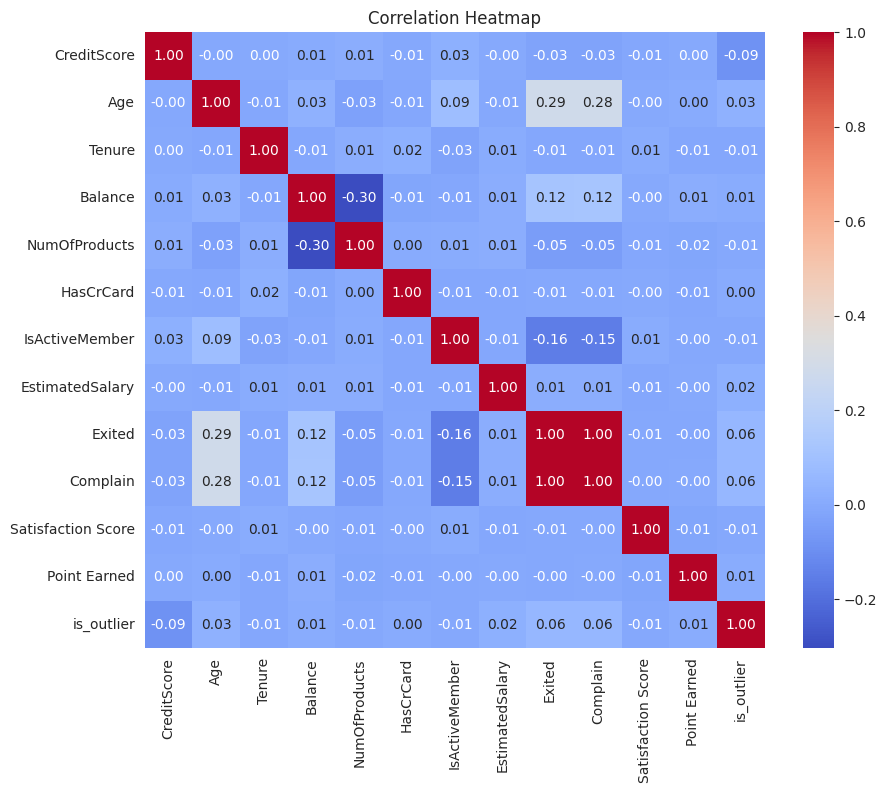

In [ ]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Feature/Target Split
X = df.drop(columns=['Exited', 'AgeGroup', 'is_outlier'])
y = df['Exited']

categorical_features = ['Geography', 'Gender', 'Card Type']
numerical_features = [c for c in X.columns if c not in categorical_features]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['Geography', 'Gender', 'Card Type']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score', 'Point Earned']


In [ ]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train churn ratio:", y_train.mean())
print("Test churn ratio:", y_test.mean())

Train churn ratio: 0.20375
Test churn ratio: 0.204


In [ ]:
# Model Training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, max_depth=None,
                                           random_state=42, n_jobs=-1))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

True Negatives: 1591 | False Positives: 1
False Negatives: 2 | True Positives: 406

⚠️ False Negatives (predicted stay, actually churned): 2


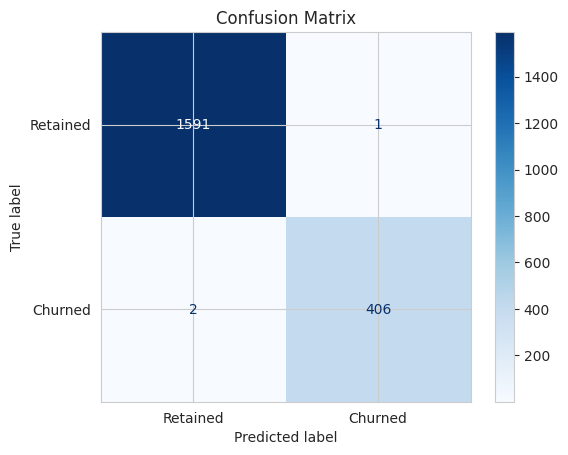

In [ ]:
# Evaluation Metrics
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} | False Positives: {fp}")
print(f"False Negatives: {fn} | True Positives: {tp}")
print(f"\n⚠️ False Negatives (predicted stay, actually churned): {fn}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      1592
     Churned       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



ROC-AUC Score: 0.9995


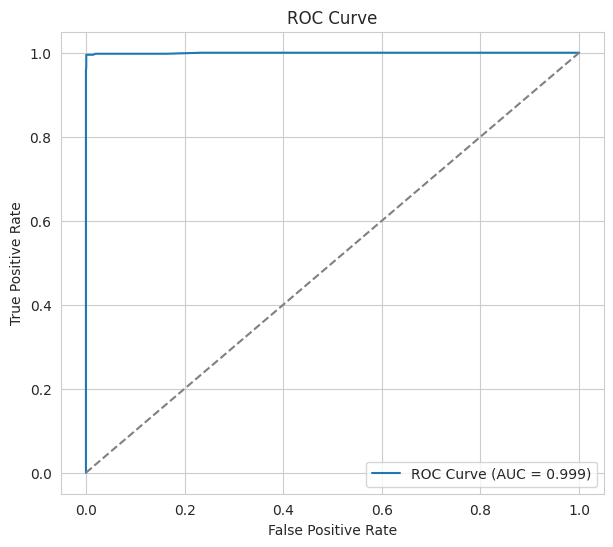

In [ ]:
# ROC-AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# Feature Importance Extraction
# Get feature names after one-hot encoding
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

importances = model_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_df.to_csv('feature_importance.csv', index=False)
feature_importance_df.head(10)

,Feature,Importance
0,Complain,0.825959
1,Age,0.063830
2,NumOfProducts,0.041275
3,Balance,0.012350
4,IsActiveMember,0.011228
5,Geography_Germany,0.010549
6,CreditScore,0.007945
7,EstimatedSalary,0.006998
8,Point Earned,0.006720
9,Tenure,0.003877


/tmp/ipykernel_999/159036603.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




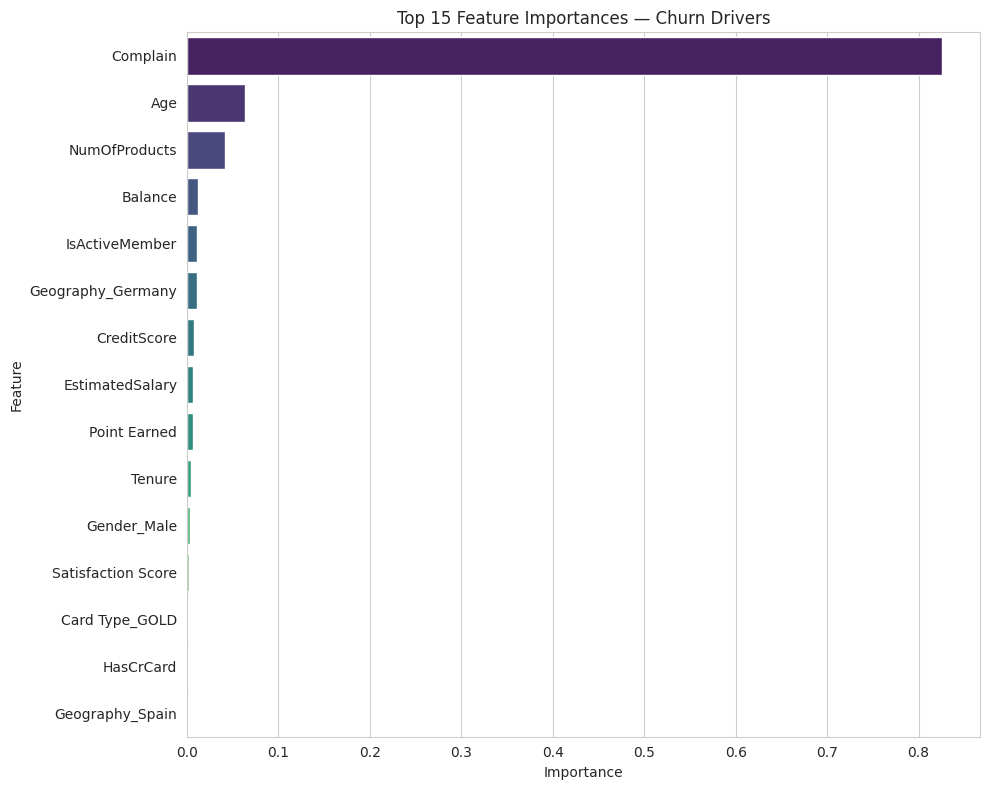

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Churn Drivers')
plt.tight_layout()
plt.show()

In [ ]:
# Downloading the outputs
files.download('cleaned_churn_data.csv')
files.download('feature_importance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  **--------- CONTINUE IN Tableau/PowerBI ---------**


